## E-Commerce Churn Analysis

The EDA shows a fairly balanced dataset from a e-commerce in terms of rate (approximately 20% consistently).

In [15]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


In [16]:
ecommerce_df = pd.read_csv('data/ecommerce_customer_data_custom_ratios.csv')
ecommerce_df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


Dataset shape, columns, data types, etc.

In [17]:
print("Shape:", ecommerce_df.shape)
print("\nColumns:", ecommerce_df.columns.tolist())
print("\nData types:")
print(ecommerce_df.dtypes)
print("\nSummary statistics:")
print(ecommerce_df.describe())

Shape: (250000, 13)

Columns: ['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']

Data types:
Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

Summary statistics:
        Customer ID  Product Price       Quantity  Total Purchase Amount  \
count  250000.00000  250000.000000  250000.000000          250000.000000   
mean    25004.03624     254.659512       2.998896            2725.370732   
std     14428.27959     141.568577       1.414694            1442.9335

## EDA

In [18]:
print(ecommerce_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 37.1 MB
None


Dataset is very clean an complete.

In [19]:
print(ecommerce_df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')


### Overall KPI

In [20]:
kpi_summary = pd.DataFrame({
    "total_customers": [ecommerce_df["Customer ID"].nunique()],
    "total_revenue": [ecommerce_df["Total Purchase Amount"].sum()],
    "total_quantity_sold": [ecommerce_df["Quantity"].sum()],
    "avg_purchase_amount": [round(ecommerce_df["Total Purchase Amount"].mean(), 2)],
    "churn_rate_percent": [round(ecommerce_df["Churn"].mean() * 100, 2)]
})

kpi_summary

,total_customers,total_revenue,total_quantity_sold,avg_purchase_amount,churn_rate_percent
0,49673,681342683,749724,2725.37,19.95


### Monthly Revenue Trend

In [21]:
ecommerce_df["Purchase Date"] = pd.to_datetime(ecommerce_df["Purchase Date"])

monthly_summary = (
    ecommerce_df
    .assign(purchase_month=ecommerce_df["Purchase Date"].dt.strftime("%Y-%m"))
    .groupby("purchase_month")
    .agg(
        monthly_revenue=("Total Purchase Amount", "sum"),
        monthly_customers=("Customer ID", "nunique"),
        monthly_quantity_sold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("purchase_month")
)

monthly_summary.head()

,purchase_month,monthly_revenue,monthly_customers,monthly_quantity_sold
0,2020-01,15442459,5376,17256
1,2020-02,14561593,5099,16172
2,2020-03,15537311,5365,17038
3,2020-04,14847491,5193,16451
4,2020-05,15395782,5429,17121


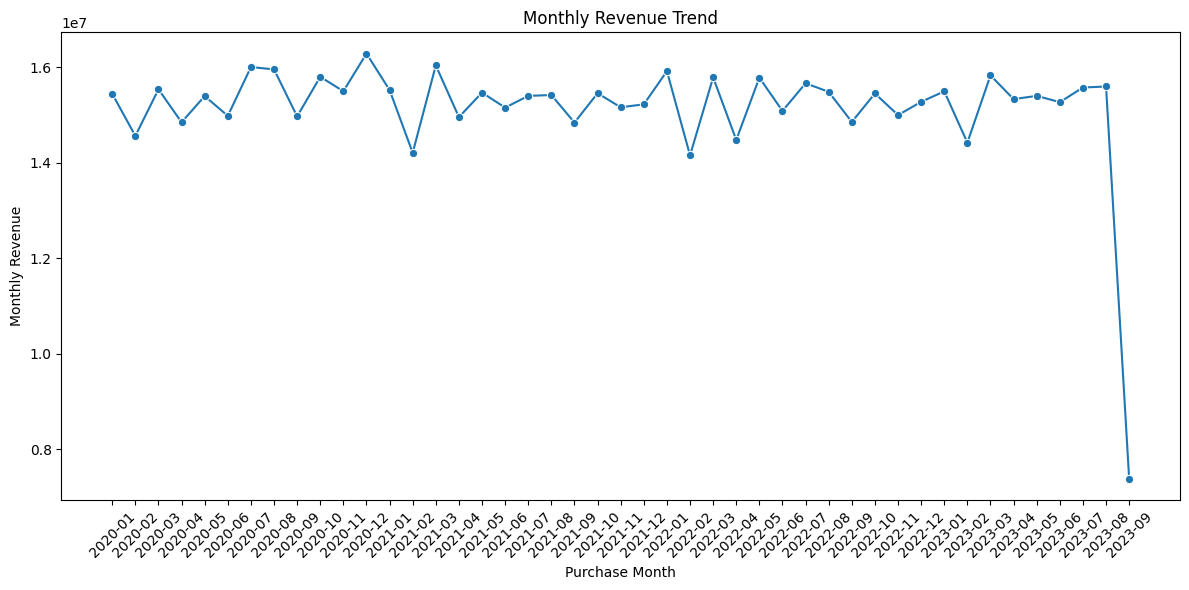

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_summary,
    x="purchase_month",
    y="monthly_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2023-09 may be inconsistent (not updated). Let's drop this month for now.

In [23]:
ecommerce_df["Purchase Date"] = pd.to_datetime(ecommerce_df["Purchase Date"])
ecommerce_df["Purchase Month"] = ecommerce_df["Purchase Date"].dt.to_period("M").astype(str)

# Drop incomplete / inconsistent month
ecommerce_df = ecommerce_df[ecommerce_df["Purchase Month"] != "2023-09"].copy()

# Check result
ecommerce_df["Purchase Month"].max()

'2023-08'

Then let's take a better look!

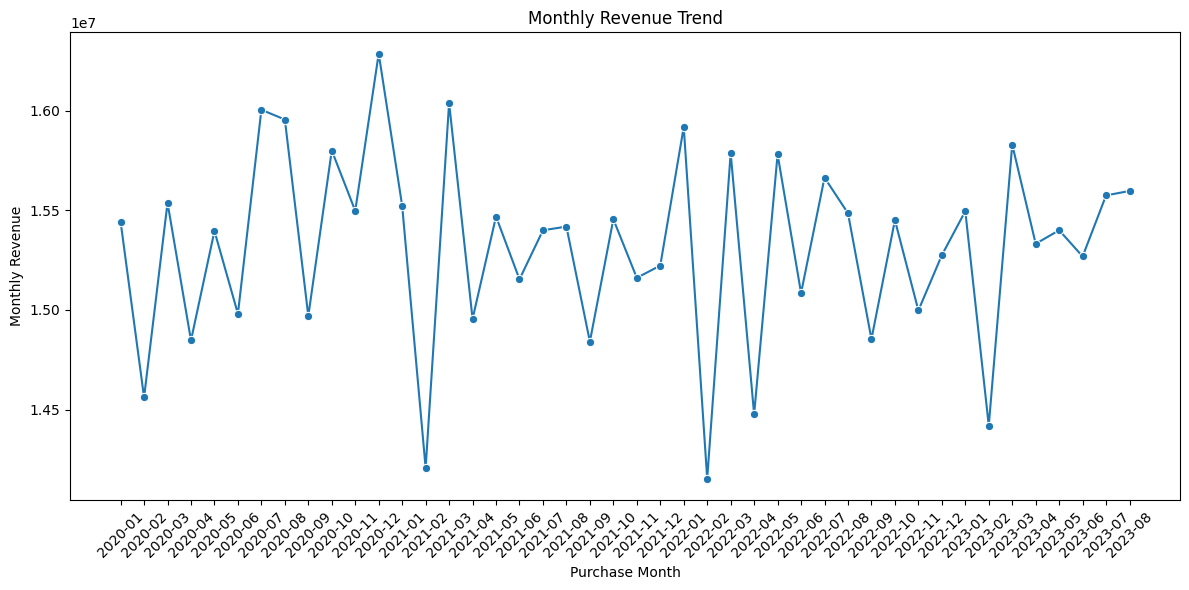

In [24]:
monthly_summary_new = (
    ecommerce_df
    .assign(purchase_month=ecommerce_df["Purchase Date"].dt.strftime("%Y-%m"))
    .groupby("purchase_month")
    .agg(
        monthly_revenue=("Total Purchase Amount", "sum"),
        monthly_customers=("Customer ID", "nunique"),
        monthly_quantity_sold=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("purchase_month")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_summary_new,
    x="purchase_month",
    y="monthly_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We notice that every February is a low point.

In [34]:
ecommerce_df["year"] = ecommerce_df["Purchase Date"].dt.year
ecommerce_df["month"] = ecommerce_df["Purchase Date"].dt.month
ecommerce_df["month_name"] = ecommerce_df["Purchase Date"].dt.month_name()
ecommerce_df["purchase_month"] = ecommerce_df["Purchase Date"].dt.strftime("%Y-%m")

# First: calculate true monthly metrics by year-month
year_month_summary = (
    ecommerce_df
    .groupby(["year", "month", "month_name", "purchase_month"])
    .agg(
        monthly_revenue=("Total Purchase Amount", "sum"),
        monthly_customers=("Customer ID", "nunique"),
        monthly_orders=("Customer ID", "count"),
        monthly_quantity=("Quantity", "sum"),
        avg_order_value=("Total Purchase Amount", "mean"),
        churn_rate=("Churn", "mean")
    )
    .reset_index()
)

year_month_summary.sort_values("monthly_revenue").head(4) # Check the lowest revenue months.

,year,month,month_name,purchase_month,monthly_revenue,monthly_customers,monthly_orders,monthly_quantity,avg_order_value,churn_rate
25,2022,2,February,2022-02,14153776,4907,5165,15484,2740.324492,0.206196
13,2021,2,February,2021-02,14207789,4893,5151,15382,2758.258396,0.199379
37,2023,2,February,2023-02,14419872,5032,5300,15840,2720.730566,0.203774
27,2022,4,April,2022-04,14477271,5080,5391,16325,2685.451864,0.198108


In [30]:
seasonality_summary = (
    year_month_summary
    .groupby(["month", "month_name"])
    .agg(
        avg_monthly_revenue=("monthly_revenue", "mean"),
        median_monthly_revenue=("monthly_revenue", "median"),
        avg_monthly_customers=("monthly_customers", "mean"),
        avg_monthly_orders=("monthly_orders", "mean"),
        avg_monthly_quantity=("monthly_quantity", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_churn_rate=("churn_rate", "mean")
    )
    .reset_index()
    .sort_values("month")
)

seasonality_summary

,month,month_name,avg_monthly_revenue,median_monthly_revenue,avg_monthly_customers,avg_monthly_orders,avg_monthly_quantity,avg_order_value,avg_churn_rate
0,1,January,1.559449e+07,15508936.5,5396.250000,5706.000000,17210.750000,2732.938235,0.198829
1,2,February,1.433576e+07,14313830.5,4982.750000,5252.500000,15719.500000,2729.726074,0.203412
2,3,March,1.579771e+07,15807878.5,5457.750000,5776.750000,17283.750000,2734.861579,0.197358
3,4,April,1.490298e+07,14901390.0,5217.750000,5512.750000,16519.000000,2703.187240,0.198702
4,5,May,1.551122e+07,15434242.0,5407.500000,5719.250000,17148.250000,2712.120919,0.200362
5,6,June,1.512194e+07,15119321.5,5230.250000,5530.500000,16588.750000,2734.305546,0.195240
6,7,July,1.566041e+07,15619074.0,5408.500000,5737.000000,17203.000000,2729.795521,0.203425
7,8,August,1.561360e+07,15540759.0,5404.250000,5727.250000,17152.500000,2726.106062,0.201701
8,9,September,1.488828e+07,14853703.0,5229.000000,5513.666667,16496.000000,2700.461412,0.197518
9,10,October,1.556835e+07,15455040.0,5396.000000,5709.333333,17068.333333,2726.934759,0.199567


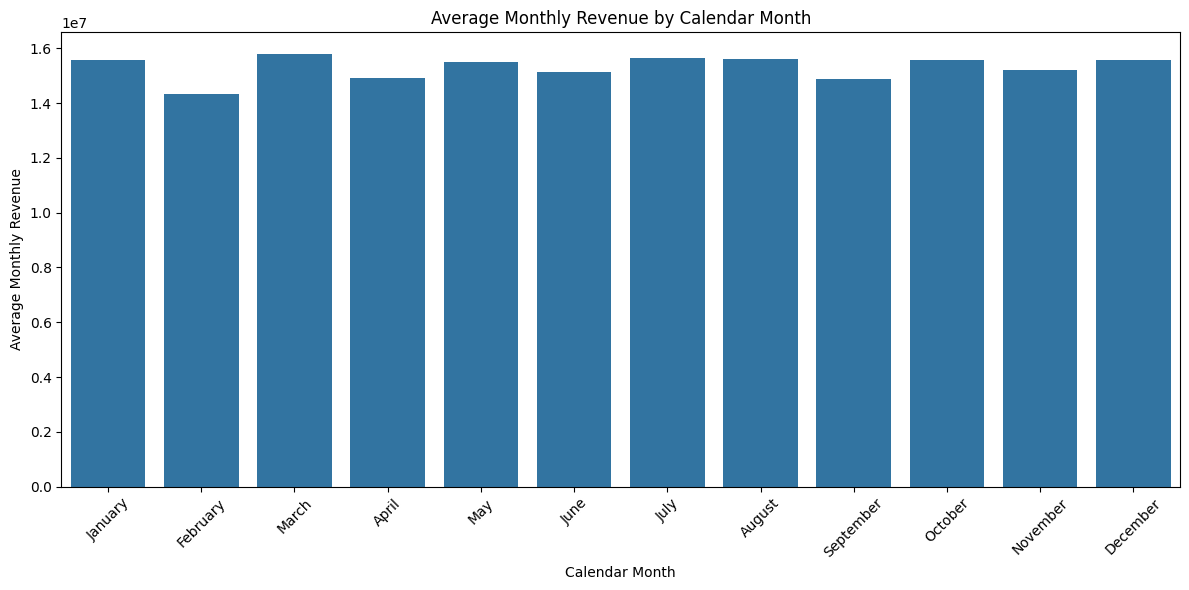

In [31]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=seasonality_summary,
    x="month_name",
    y="avg_monthly_revenue"
)

plt.title("Average Monthly Revenue by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Indeed, February has the lowest average monthly revenue among all calendar months.

The February revenue dip appears to be driven by a combination of higher churn rate, fewer customers, fewer orders, and lower quantity sold. However, the average order value is not substantially lower, suggesting that the issue is more related to lower customer activity and retention rather than smaller purchase size.

This may indicate a potential retention or demand problem in February.

### Simple prediction using Constant Model & OLS

In [35]:
# Make sure monthly data is sorted
monthly_summary_new = monthly_summary_new.sort_values("purchase_month").reset_index(drop=True)
monthly_summary_new["t"] = np.arange(len(monthly_summary_new))

# 1. Constant model
constant_forecast_value = monthly_summary_new["monthly_revenue"].mean()

# 2. OLS trend model
X = monthly_summary_new[["t"]]
y = monthly_summary_new["monthly_revenue"]

ols_model = LinearRegression()
ols_model.fit(X, y)

# Forecast next 6 months
future_periods = 6
last_month = pd.Period(monthly_summary_new["purchase_month"].max(), freq="M")

future_months = [
    str(last_month + i) for i in range(1, future_periods + 1)
]

future_t = np.arange(
    len(monthly_summary_new),
    len(monthly_summary_new) + future_periods
).reshape(-1, 1)

ols_forecast = ols_model.predict(future_t)

forecast_df = pd.DataFrame({
    "purchase_month": future_months,
    "constant_model_forecast": constant_forecast_value,
    "ols_trend_forecast": ols_forecast
})

forecast_df

c:\Users\KPdesktop\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,purchase_month,constant_model_forecast,ols_trend_forecast
0,2023-09,1.531729e+07,1.529885e+07
1,2023-10,1.531729e+07,1.529803e+07
2,2023-11,1.531729e+07,1.529722e+07
3,2023-12,1.531729e+07,1.529640e+07
4,2024-01,1.531729e+07,1.529558e+07
5,2024-02,1.531729e+07,1.529476e+07


Using only recent 12 months, and Visualize the trends:

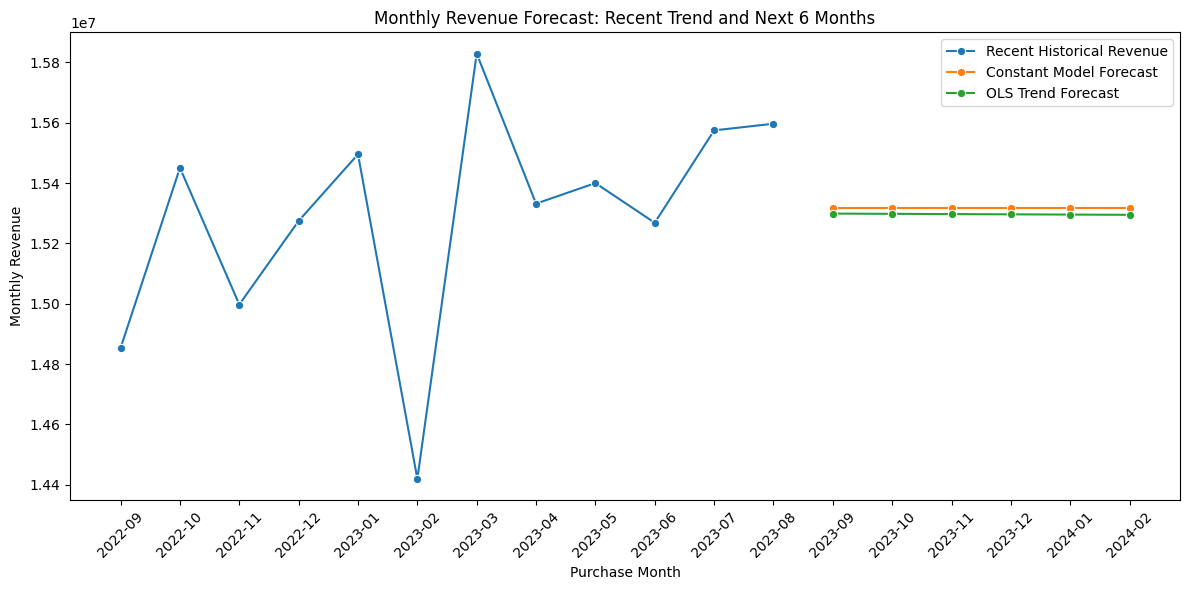

Constant model forecast: 15317293.18
OLS slope: -819.52
OLS intercept: 15334912.81


In [36]:
# Keep recent historical months only
recent_months = 12
recent_history = monthly_summary_new.tail(recent_months).copy()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=recent_history,
    x="purchase_month",
    y="monthly_revenue",
    marker="o",
    label="Recent Historical Revenue"
)

# Constant forecast
sns.lineplot(
    data=forecast_df,
    x="purchase_month",
    y="constant_model_forecast",
    marker="o",
    label="Constant Model Forecast"
)

# OLS forecast
sns.lineplot(
    data=forecast_df,
    x="purchase_month",
    y="ols_trend_forecast",
    marker="o",
    label="OLS Trend Forecast"
)

plt.title("Monthly Revenue Forecast: Recent Trend and Next 6 Months")
plt.xlabel("Purchase Month")
plt.ylabel("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Constant model forecast:", round(constant_forecast_value, 2))
print("OLS slope:", round(ols_model.coef_[0], 2))
print("OLS intercept:", round(ols_model.intercept_, 2))

### Product Category Performance

In [37]:
category_summary = (
    ecommerce_df
    .groupby("Product Category")
    .agg(
        category_revenue=("Total Purchase Amount", "sum"),
        quantity_sold=("Quantity", "sum"),
        unique_customers=("Customer ID", "nunique")
    )
    .reset_index()
)

category_summary["revenue_per_customer"] = round(
    category_summary["category_revenue"] / category_summary["unique_customers"],
    2
)

category_summary = category_summary.sort_values(
    "category_revenue",
    ascending=False
).reset_index(drop=True)

category_summary

,Product Category,category_revenue,quantity_sold,unique_customers,revenue_per_customer
0,Books,202658814,221385,38581,5252.81
1,Clothing,202316118,222893,38640,5235.92
2,Electronics,135167996,149315,31578,4280.45
3,Home,133817972,148136,31408,4260.63


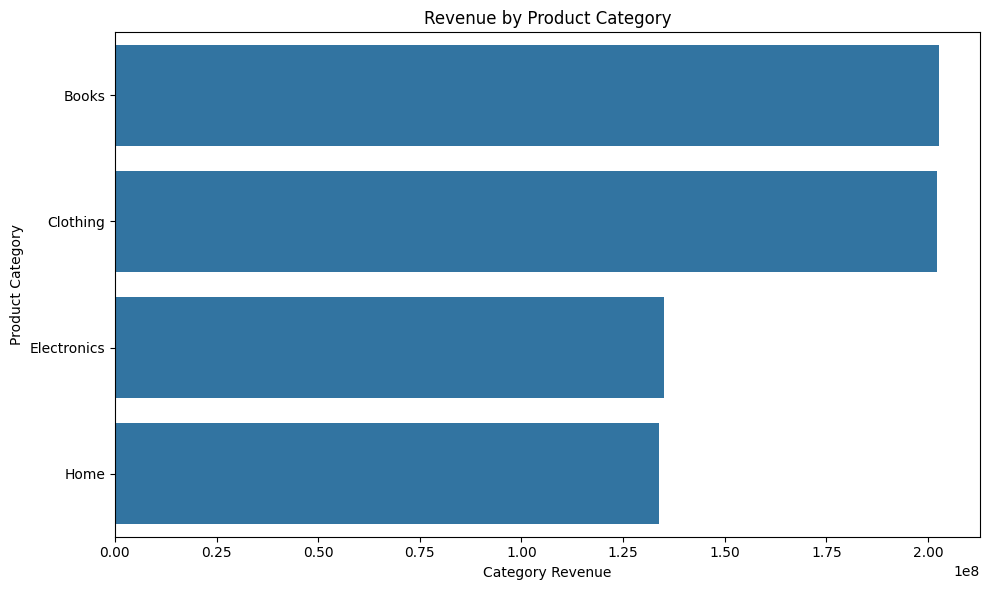

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_summary,
    x="category_revenue",
    y="Product Category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Category Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Product Category + Churn

In [39]:
category_churn_summary = (
    ecommerce_df
    .groupby("Product Category")
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Purchase Amount", "sum"),
        churn_rate_percent=("Churn", lambda x: round(x.mean() * 100, 2))
    )
    .reset_index()
)

category_churn_summary["revenue_per_customer"] = round(
    category_churn_summary["total_revenue"] / category_churn_summary["customers"],
    2
)

category_churn_summary = (
    category_churn_summary
    .sort_values("churn_rate_percent", ascending=False)
    .reset_index(drop=True)
)

category_churn_summary

,Product Category,customers,total_revenue,churn_rate_percent,revenue_per_customer
0,Home,31408,133817972,20.22,4260.63
1,Books,38581,202658814,19.91,5252.81
2,Clothing,38640,202316118,19.87,5235.92
3,Electronics,31578,135167996,19.87,4280.45


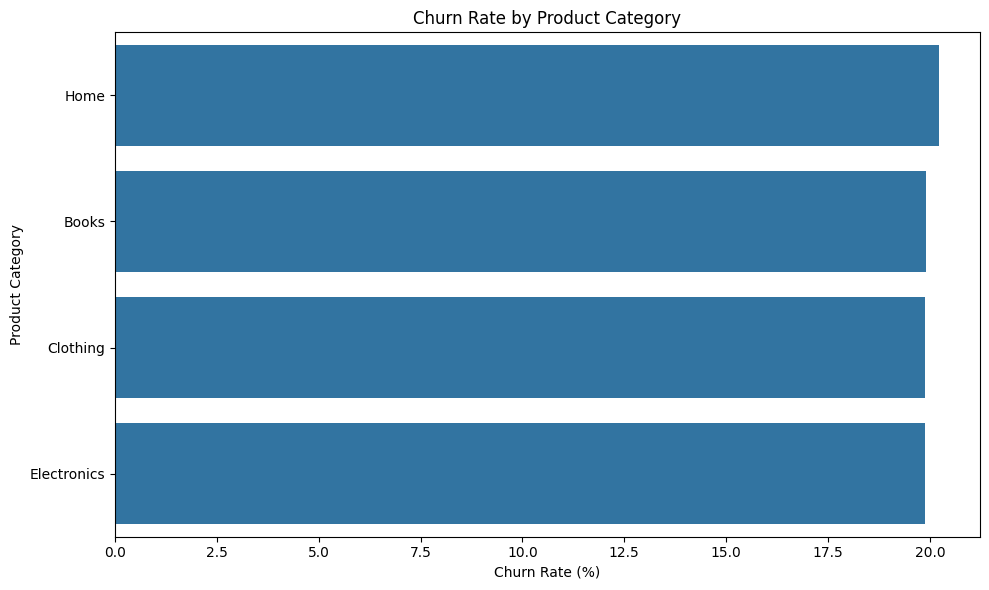

In [40]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_churn_summary,
    x="churn_rate_percent",
    y="Product Category"
)

plt.title("Churn Rate by Product Category")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Age Group Churn

In [41]:

ecommerce_df["age_group"] = np.select(
    [
        ecommerce_df["Age"] < 25,
        ecommerce_df["Age"].between(25, 34),
        ecommerce_df["Age"].between(35, 44),
        ecommerce_df["Age"].between(45, 54)
    ],
    [
        "Under 25",
        "25-34",
        "35-44",
        "45-54"
    ],
    default="55+"
)

age_group_summary = (
    ecommerce_df
    .groupby("age_group")
    .agg(
        customers=("Customer ID", "nunique"),
        churn_rate_percent=("Churn", lambda x: round(x.mean() * 100, 2)),
        total_revenue=("Total Purchase Amount", "sum"),
        avg_purchase_amount=("Total Purchase Amount", lambda x: round(x.mean(), 2))
    )
    .reset_index()
    .sort_values("churn_rate_percent", ascending=False)
    .reset_index(drop=True)
)

age_group_summary

,age_group,customers,churn_rate_percent,total_revenue,avg_purchase_amount
0,Under 25,6688,20.95,87193991,2617.42
1,45-54,9267,19.92,127411861,2756.82
2,55+,15003,19.88,210019665,2811.66
3,35-44,9335,19.75,125948661,2705.32
4,25-34,9366,19.61,123386722,2650.86


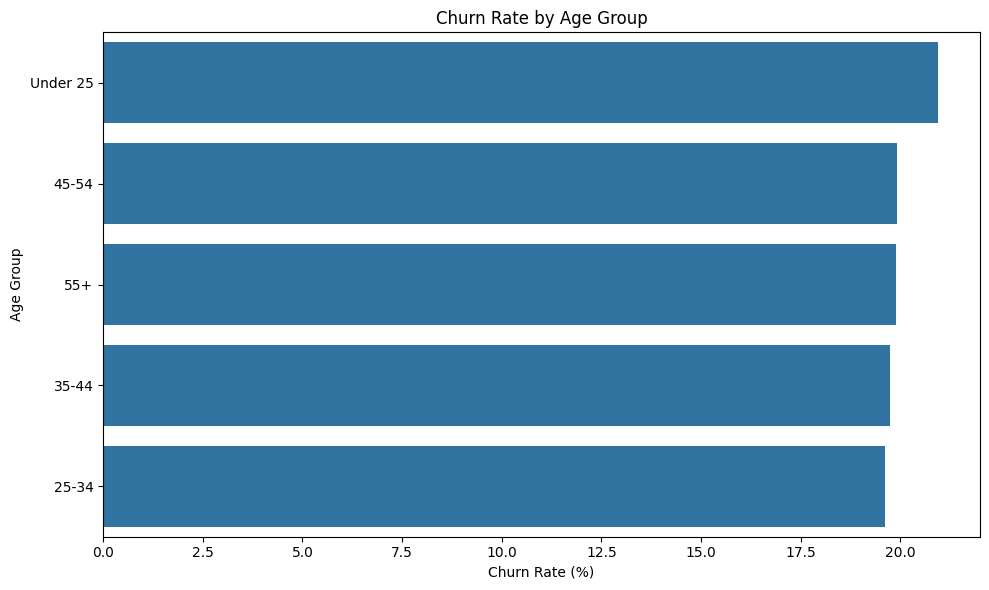

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_group_summary,
    x="churn_rate_percent",
    y="age_group"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

### Gender + Churn, Gender + Revenue

In [43]:
gender_summary = (
    ecommerce_df
    .groupby("Gender")
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Purchase Amount", "sum"),
        churn_rate_percent=("Churn", lambda x: round(x.mean() * 100, 2)),
        avg_purchase_amount=("Total Purchase Amount", lambda x: round(x.mean(), 2))
    )
    .reset_index()
    .sort_values("churn_rate_percent", ascending=False)
    .reset_index(drop=True)
)

gender_summary

,Gender,customers,total_revenue,churn_rate_percent,avg_purchase_amount
0,Male,24708,335207960,20.29,2723.21
1,Female,24951,338752940,19.62,2726.71


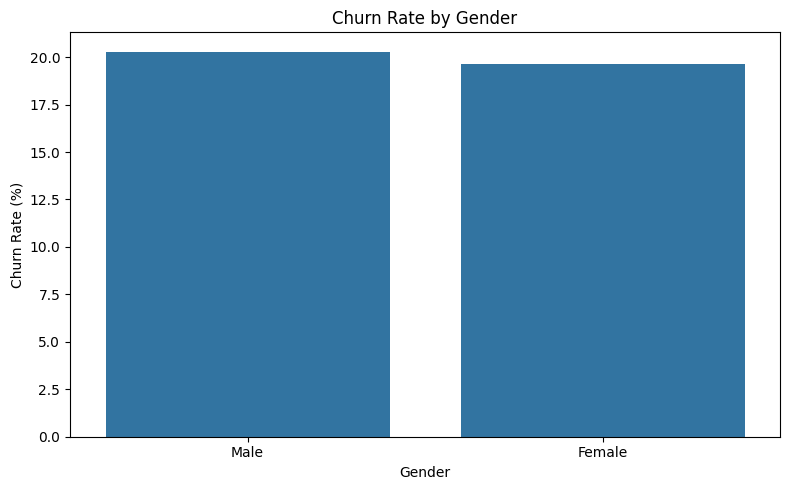

In [44]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_summary,
    x="Gender",
    y="churn_rate_percent"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

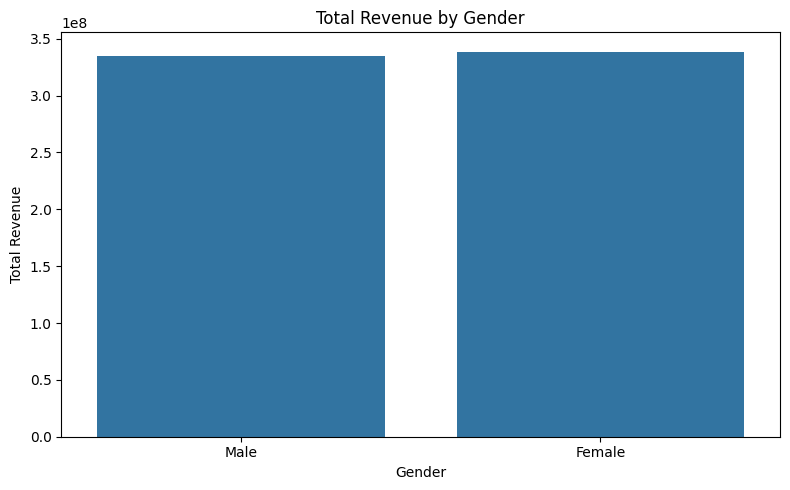

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_summary,
    x="Gender",
    y="total_revenue"
)

plt.title("Total Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

### Returns + Churn

In [46]:
return_summary = (
    ecommerce_df
    .assign(
        return_status=np.where(
            ecommerce_df["Returns"] > 0,
            "Had Return",
            "No Return"
        )
    )
    .groupby("return_status")
    .agg(
        customers=("Customer ID", "nunique"),
        total_revenue=("Total Purchase Amount", "sum"),
        churn_rate_percent=("Churn", lambda x: round(x.mean() * 100, 2)),
        avg_purchase_amount=("Total Purchase Amount", lambda x: round(x.mean(), 2))
    )
    .reset_index()
    .sort_values("churn_rate_percent", ascending=False)
    .reset_index(drop=True)
)

return_summary

,return_status,customers,total_revenue,churn_rate_percent,avg_purchase_amount
0,Had Return,43081,271632447,20.00,2724.91
1,No Return,47457,402328453,19.92,2725.01


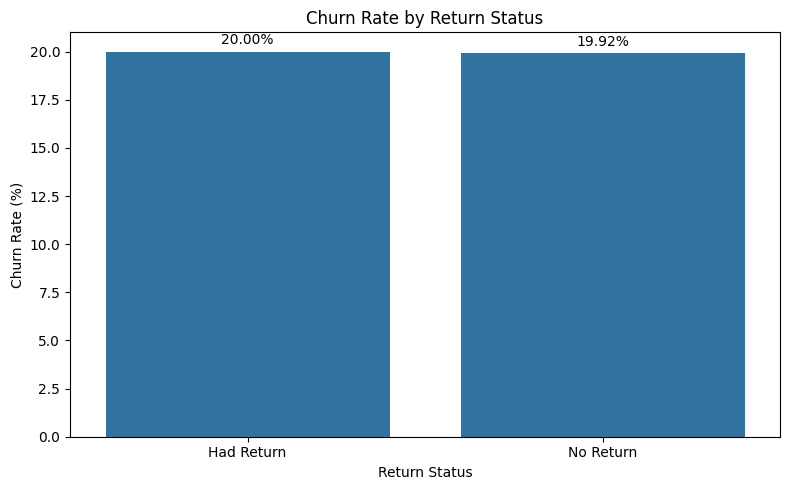

In [47]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=return_summary,
    x="return_status",
    y="churn_rate_percent"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f%%",
    padding=3
)

plt.title("Churn Rate by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

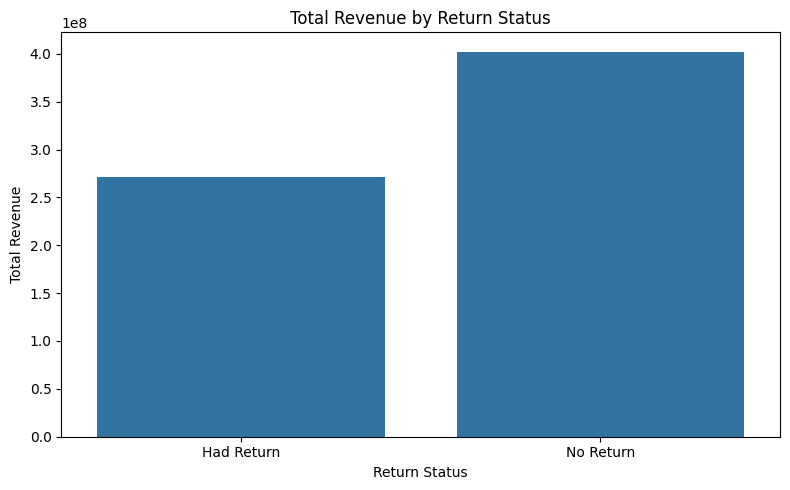

In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=return_summary,
    x="return_status",
    y="total_revenue"
)

plt.title("Total Revenue by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

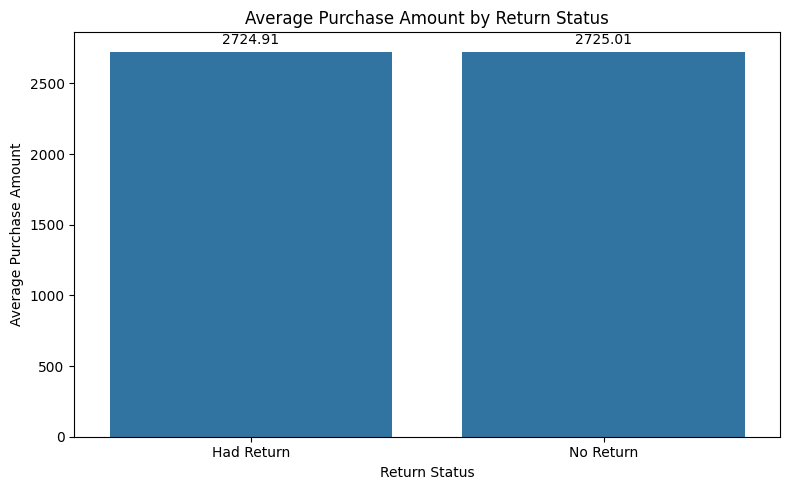

In [49]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=return_summary,
    x="return_status",
    y="avg_purchase_amount"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=3
)

plt.title("Average Purchase Amount by Return Status")
plt.xlabel("Return Status")
plt.ylabel("Average Purchase Amount")
plt.tight_layout()
plt.show()

As we can see, total revenue negatively correlates with return rate, we need to lower the return rate, especially during February.